# QHY42 Camera Analysis

### 1. Quick PTC: 2 pts per exposure time

This follows the general Janesick approach of having two exposures at each exposure time and using them to remove the FPN from the PTC.

In [1]:
# Import modules

import os
from pathlib import Path
from glob import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from analysis.utils.utils import plot_image


In [2]:
import os, json
from glob import glob

import numpy as np
import pandas as pd
from astropy.io import fits

def get_exptime_from_filename(filename) -> float:
    exp_time_str = filename.replace("std_stream_", "").replace(".fits", "")
    exp_time_ms = float(exp_time_str.replace("_ms", ""))
    exp_time_s = exp_time_ms / 1000.0
    return round(exp_time_s, 6)  # normalize to avoid floating point issues


def read_fits_stack(filepath: str):
    """
    Returns:
      data: np.ndarray with shape (n, y, x) or (y, x) if truly single-frame
      n_images: int
      header: fits.Header (primary header)
    """
    with fits.open(filepath, memmap=False) as hdul:
        primary_header = hdul[0].header

        # 1) If any HDU contains a 3D cube, use the first one we find.
        for hdu in hdul:
            if hdu.data is None:
                continue
            arr = np.asarray(hdu.data, dtype=np.float32)
            if arr.ndim == 3:
                return arr, int(arr.shape[0]), primary_header

        # 2) Otherwise, collect all 2D image HDUs and stack them.
        frames = []
        for hdu in hdul:
            if hdu.data is None:
                continue
            arr = np.asarray(hdu.data, dtype=np.float32)
            if arr.ndim == 2:
                frames.append(arr)

        if len(frames) >= 2:
            cube = np.stack(frames, axis=0).astype(np.float32)  # (n, y, x)
            return cube, int(cube.shape[0]), primary_header

        # 3) Fallback: single frame
        if len(frames) == 1:
            return frames[0].astype(np.float32), 1, primary_header

        return None, 0, primary_header


def build_database(dirs_to_load) -> pd.DataFrame:
    data_records = []

    for data_dir in dirs_to_load:
        try:
            run_info_path = os.path.join(data_dir, "run_info.json")
            with open(run_info_path, "r") as f:
                run_info = json.load(f)

            frame_type = run_info["frame_type"].lower()
            print(f"Loading {frame_type} frames from {data_dir}")

            files = sorted(glob(os.path.join(data_dir, "std_stream_*.fits")))
            print(f"found {len(files)} files in {data_dir}")

            for filepath in files:
                filename = os.path.basename(filepath)
                exptime_s = get_exptime_from_filename(filename)

                data, n_images, header = read_fits_stack(filepath)

                data_records.append({
                    "filename": filename,
                    "filepath": str(filepath),
                    "frame_type": frame_type,
                    "exposure_time": exptime_s,
                    "n_images": n_images,
                    "header": header,
                    "data": data,
                })

        except Exception as e:
            print(f"could not load data from {data_dir}: {e}")

    df = pd.DataFrame(data_records)
    return df.sort_values(["frame_type", "exposure_time"]).reset_index(drop=True)


In [3]:
# Import the data

BOX_PATH = os.path.join(os.getenv("HOME"), "Library", "CloudStorage", "Box-Box")

DATA_DIR = os.path.join(BOX_PATH, "Scientific CMOS - MKI ONLY (might contain EAR; ITAR)",
                        "QHY42", "ramps",
                        "20260114")

light_dir = os.path.join(DATA_DIR, "20260114_170530_ramp")
dark_dir = os.path.join(DATA_DIR, "20260114_171156_ramp")

# The files all have names like: std_stream_17.4_ms.fits
# we need to parse the filename to grab the exposure time in ms

# in each folder there is a run_info.json file which has information about the ramp

dirs_to_load = [light_dir, dark_dir]

raw_df = build_database(dirs_to_load)





Loading light frames from /Users/nlourie/Library/CloudStorage/Box-Box/Scientific CMOS - MKI ONLY (might contain EAR; ITAR)/QHY42/ramps/20260114/20260114_170530_ramp
found 50 files in /Users/nlourie/Library/CloudStorage/Box-Box/Scientific CMOS - MKI ONLY (might contain EAR; ITAR)/QHY42/ramps/20260114/20260114_170530_ramp
Loading dark frames from /Users/nlourie/Library/CloudStorage/Box-Box/Scientific CMOS - MKI ONLY (might contain EAR; ITAR)/QHY42/ramps/20260114/20260114_171156_ramp
found 50 files in /Users/nlourie/Library/CloudStorage/Box-Box/Scientific CMOS - MKI ONLY (might contain EAR; ITAR)/QHY42/ramps/20260114/20260114_171156_ramp


In [4]:
raw_df["frame_type"].value_counts()

# distribution of stack lengths (you expect mostly 25)
raw_df["n_images"].value_counts().sort_index()

# find weird ones
raw_df.loc[raw_df["n_images"] != 25, ["frame_type", "exposure_time", "filename", "n_images"]]


,frame_type,exposure_time,filename,n_images
0,dark,0.0100,std_stream_10.0_ms.fits,19
1,dark,0.0106,std_stream_10.6_ms.fits,16
2,dark,0.0112,std_stream_11.2_ms.fits,16
3,dark,0.0118,std_stream_11.8_ms.fits,23
4,dark,0.0125,std_stream_12.5_ms.fits,16
5,dark,0.0132,std_stream_13.2_ms.fits,23
6,dark,0.0139,std_stream_13.9_ms.fits,23
51,light,0.0106,std_stream_10.6_ms.fits,23
52,light,0.0112,std_stream_11.2_ms.fits,19
53,light,0.0118,std_stream_11.8_ms.fits,18


In [5]:
from typing import Tuple

def get_roi_data(
    data: np.ndarray,
    roi_center: Tuple[int, int],
    roi_width: int
) -> np.ndarray:
    """
    Extract a square ROI from a single frame or from each frame in a data cube.

    Args:
        data: np.ndarray with shape (ny, nx) or (n_frames, ny, nx)
        roi_center: (y_center, x_center)
        roi_width: width of the square ROI (pixels)

    Returns:
        roi_data:
            - (roi_width, roi_width) if input is 2D
            - (n_frames, roi_width, roi_width) if input is 3D
    """
    if data.ndim not in (2, 3):
        raise ValueError(f"data must be 2D or 3D, got shape {data.shape}")

    y0, x0 = roi_center
    half = roi_width // 2

    y_slice = slice(y0 - half, y0 + half)
    x_slice = slice(x0 - half, x0 + half)

    # Bounds check (fail loudly — better than silent wrap)
    ny, nx = data.shape[-2:]
    if not (0 <= y_slice.start and y_slice.stop <= ny and
            0 <= x_slice.start and x_slice.stop <= nx):
        raise ValueError(
            f"ROI out of bounds: center={roi_center}, width={roi_width}, "
            f"data shape={data.shape}"
        )

    if data.ndim == 2:
        # (ny, nx) -> (roi, roi)
        return data[y_slice, x_slice]

    else:
        # (n, ny, nx) -> (n, roi, roi)
        return data[:, y_slice, x_slice]


Unique exposure times (s): [0.01   0.0106 0.0112 0.0118 0.0125 0.0132 0.0139 0.0147 0.0156 0.0164
 0.0174 0.0184 0.0194 0.0205 0.0217 0.0229 0.0242 0.0256 0.027  0.0286
 0.0302 0.0319 0.0337 0.0356 0.0377 0.0398 0.0421 0.0445 0.047  0.0497
 0.0525 0.0555 0.0586 0.062  0.0655 0.0692 0.0731 0.0773 0.0817 0.0863
 0.0912 0.0964 0.1019 0.1077 0.1138 0.1202 0.1271 0.1343 0.1419 0.15  ]
Found 1 light rows for exptime 0.01s
Found 1 dark rows for exptime 0.01s
Statistical Read Noise at 0.01s: 36.60 ADU


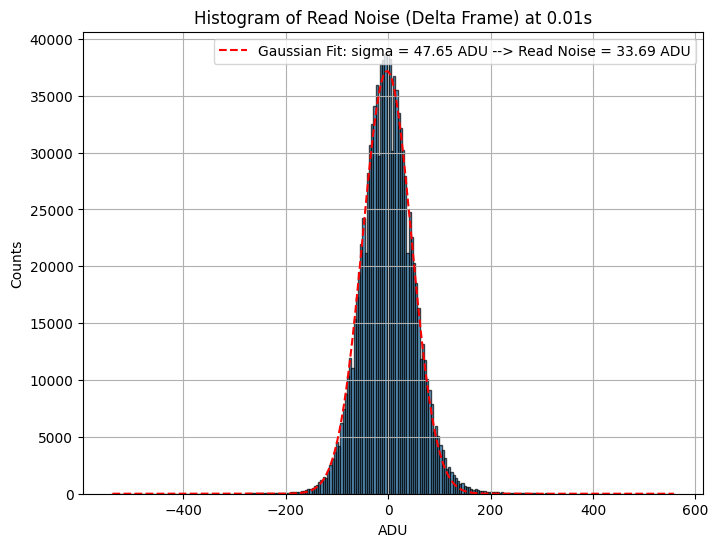

Gaussian Fit at 0.01s: $\sigma$ = 47.65 --> 33.69 ADU
Found 1 light rows for exptime 0.0106s
Found 1 dark rows for exptime 0.0106s
Found 1 light rows for exptime 0.0112s
Found 1 dark rows for exptime 0.0112s
Found 1 light rows for exptime 0.0118s
Found 1 dark rows for exptime 0.0118s
Found 1 light rows for exptime 0.0125s
Found 1 dark rows for exptime 0.0125s
Found 1 light rows for exptime 0.0132s
Found 1 dark rows for exptime 0.0132s
Found 1 light rows for exptime 0.0139s
Found 1 dark rows for exptime 0.0139s
Found 1 light rows for exptime 0.0147s
Found 1 dark rows for exptime 0.0147s
Found 1 light rows for exptime 0.0156s
Found 1 dark rows for exptime 0.0156s
Found 1 light rows for exptime 0.0164s
Found 1 dark rows for exptime 0.0164s
Found 1 light rows for exptime 0.0174s
Found 1 dark rows for exptime 0.0174s
Found 1 light rows for exptime 0.0184s
Found 1 dark rows for exptime 0.0184s
Found 1 light rows for exptime 0.0194s
Found 1 dark rows for exptime 0.0194s
Found 1 light rows for

In [6]:
# process the data
unique_exposure_times = raw_df['exposure_time'].unique()

print("Unique exposure times (s):", unique_exposure_times)

# make a processed dataframe
df = raw_df.copy()

# sort the dataframe to ensure deterministic selection of first row
df = df.sort_values(
    by=["frame_type", "exposure_time", "filename"]
)

results = []

# define ROI
roi_center = (1024, 1024)  # (y, x)
roi_width = 1024  # pixels

# Now step through each unique exposure time and work through the PTC analysis
#unique_exposure_times = [2.005]

debug_plots = False
for i, exptime in enumerate(unique_exposure_times):
    
    light_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "light")
    ]
    print(f"Found {len(light_rows)} light rows for exptime {exptime}s")


    dark_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "dark")
    ]

    print(f"Found {len(dark_rows)} dark rows for exptime {exptime}s")

    light_data_1 = light_rows.iloc[0]["data"][0]

    #plot_image(light_data_1, title=f"Light Frame 1 - Exptime {exptime}s")

    light_data_2 = light_rows.iloc[0]["data"][1]
    dark_data_1 = dark_rows.iloc[0]["data"][0]
    dark_data_2 = dark_rows.iloc[0]["data"][1]
    all_dark_data = dark_rows.iloc[0]["data"]

    if i==0:
        # calculate the read noise from the shortest exposure time darks
        all_dark_except_last_frame_data = dark_rows.iloc[0]["data"][:-1]
        avg_dark_except_last_frame = np.mean(all_dark_except_last_frame_data, axis=0)
        last_dark_data = dark_rows.iloc[0]["data"][-1]
        
        
    # make an average of all the dark frames for this exposure time
    avg_dark_frame = np.mean(all_dark_data, axis=0)
    

    if roi_center is not None:
        light_data_1 = get_roi_data(light_data_1, roi_center, roi_width)
        light_data_2 = get_roi_data(light_data_2, roi_center, roi_width)
        dark_data_1 = get_roi_data(dark_data_1, roi_center, roi_width)
        dark_data_2 = get_roi_data(dark_data_2, roi_center, roi_width)
        avg_dark_frame = get_roi_data(avg_dark_frame, roi_center, roi_width)

        if i==0:
            avg_dark_except_last_frame = get_roi_data(avg_dark_except_last_frame, roi_center, roi_width)
            last_dark_data = get_roi_data(last_dark_data, roi_center, roi_width)
            
    if i==0:
        delta_read_noise_frame = last_dark_data - avg_dark_except_last_frame
        read_noise_stat = np.std(delta_read_noise_frame)/np.sqrt(2)
        print(f"Statistical Read Noise at {exptime}s: {read_noise_stat:.2f} ADU")
        
        # make a histogram of delta_read_noise_frame and fit with a gaussian
        plt.figure(figsize=(8,6))
        hist, bin_edges = np.histogram(delta_read_noise_frame.flatten(), bins=256)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', alpha=0.7)
        plt.title(f"Histogram of Read Noise (Delta Frame) at {exptime}s")
        plt.xlabel("ADU")
        plt.ylabel("Counts")
        plt.grid()

        # fit a gaussian to the histogram
        from scipy.optimize import curve_fit
        def gaussian(x, amp, mean, stddev):
            return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))
        gaussian_initial_guess = [np.max(hist), 0, read_noise_stat]
        popt, pcov = curve_fit(gaussian, bin_centers, hist, p0=gaussian_initial_guess)
        amp_fit, mean_fit, stddev_fit = popt   

        # update the readnoise from the fit
        read_noise = stddev_fit/np.sqrt(2)

        plt.plot(bin_centers, gaussian(bin_centers, *popt), 'r--', label=f'Gaussian Fit: sigma = {stddev_fit:.2f} ADU --> Read Noise = {read_noise:.2f} ADU')
        plt.legend()
        plt.show()
        
        print(f"Gaussian Fit at {exptime}s: $\sigma$ = {stddev_fit:.2f} --> {read_noise:.2f} ADU")


    if debug_plots:
        plot_image(light_data_1, title=f"Light Frame 1 - Exptime {exptime}s")
        plot_image(light_data_2, title=f"Light Frame 2 - Exptime {exptime}s")
        plot_image(avg_dark_frame, title=f"Average Dark Frame - Exptime {exptime}s")

    light_avg = np.average(light_data_1)

    signal = light_data_1 - avg_dark_frame
    signal_avg = np.average(signal)

    sigma_total = np.std(signal) # total noise (read + shot + fpn)

    delta = light_data_1 - light_data_2 # difference of two raw light frames

    if debug_plots:
        plot_image(delta, title=f"Delta Frame - Exptime {exptime}s")
    sigma_delta = np.std(delta)
    sigma_read_plus_shot = sigma_delta / np.sqrt(2) # read + shot noise

    # sigma_shot = sigma_read_plus_shot - read_noise
    sigma_shot = np.sqrt(sigma_read_plus_shot**2 - read_noise**2)
    
    # sigma_fpn = np.sqrt(sigma_total**2 - sigma_read_plus_shot**2)
    sigma_fpn = np.sqrt(sigma_total**2 - sigma_read_plus_shot**2)

    results.append({
        "exposure_time": exptime,
        "light_avg": light_avg,
        "signal_avg": signal_avg,
        "sigma_total": sigma_total,
        "delta" : delta,
        "sigma_read_plus_shot": sigma_read_plus_shot,
        "sigma_shot" : sigma_shot,
        "sigma_fpn" : sigma_fpn,
        

    })


results_df = pd.DataFrame(results)



In [7]:
# Calculate Read Noise from the shortest dark exposure time
shortest_dark_exptime = results_df["exposure_time"].min()

Using gain point signal: 20099.1171875 ADU
Calculated Gain: K = 0.04 e-/ADU
Maximum Total Noise: 1277.44 ADU
Estimated Full Well: 51894 DN = 2133 e-
Estimated Dynamic Range: 1540.10 
Estimated Dynamic Range: 63.75 dB 
Estimated Dynamic Range: 10.59 stops 


Text(0.5, 1.0, 'QHY42 Photon Transfer Curve (PTC): Gain = 7, Offset = 100')

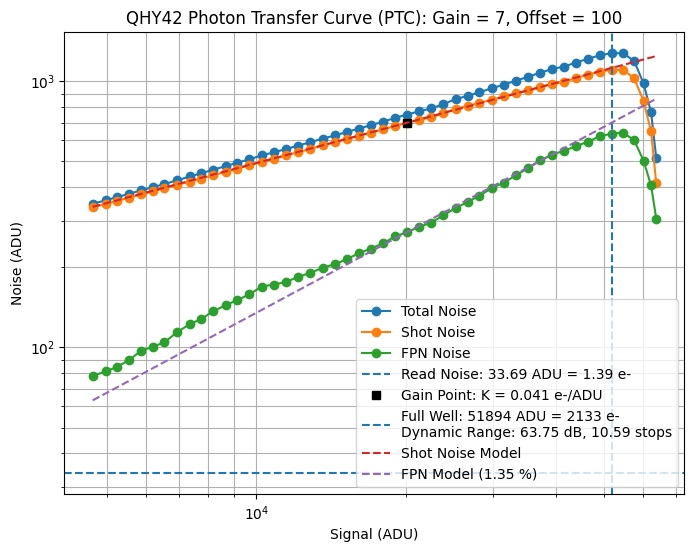

In [8]:
# analyze the PTC
exposure_times = results_df["exposure_time"][:-1]
signal = results_df["signal_avg"][:-1]
sigma_total = results_df["sigma_total"][:-1]
sigma_shot = results_df["sigma_shot"][:-1]
sigma_fpn = results_df["sigma_fpn"][:-1]

# pick a point to calculate the gain
gain_point_signal = 20000  # ADU
# find the closest signal value in the results_df
gain_point_idx = (np.abs(signal - gain_point_signal)).argmin()
gain_point_signal_actual = signal.iloc[gain_point_idx]
print(f"Using gain point signal: {gain_point_signal_actual} ADU")
gain_point_sigma_shot = sigma_shot.iloc[gain_point_idx]
gain = gain_point_signal_actual / (gain_point_sigma_shot ** 2)
print(f"Calculated Gain: K = {gain:.2f} e-/ADU")

# full well analysis: 
max_sigma_total = np.max(sigma_total)
print(f"Maximum Total Noise: {max_sigma_total:.2f} ADU")
fw = signal[np.argmax(sigma_total)]
print(f"Estimated Full Well: {fw:.0f} DN = {fw*gain:.0f} e-")    
dynamic_range = fw / read_noise
print(f"Estimated Dynamic Range: {dynamic_range:.2f} ")

dynamic_range_db = 20 * np.log10(dynamic_range)
print(f"Estimated Dynamic Range: {dynamic_range_db:.2f} dB ")

dynamic_range_stops = dynamic_range_db/(20*np.log10(2))
print(f"Estimated Dynamic Range: {dynamic_range_stops:.2f} stops ")

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(signal, sigma_total, 'o-', label = "Total Noise")
ax.plot(signal, sigma_shot, 'o-', label = "Shot Noise")
ax.plot(signal, sigma_fpn, 'o-', label = "FPN Noise")
ax.axhline(read_noise, linestyle='--', label=f'Read Noise: {read_noise:.2f} ADU = {read_noise*gain:.2f} e- ')

ax.plot(gain_point_signal_actual, gain_point_sigma_shot, 'ks', label=f'Gain Point: K = {gain:.3f} e-/ADU')

ax.axvline(fw, linestyle='--', label=f'Full Well: {fw:.0f} ADU = {fw*gain:.0f} e- \nDynamic Range: {dynamic_range_db:.2f} dB, {dynamic_range_stops:.2f} stops')

# plot gain line
shot_noise_gain_line = np.sqrt(signal / gain)
ax.plot(signal, shot_noise_gain_line, '--', label = "Shot Noise Model")

# pick a point to calculate FPN %
fpn_point_signal = 20000  # ADU
# find the closest signal value in the results_df
fpn_point_idx = (np.abs(signal - fpn_point_signal)).argmin()
fpn_point_signal_actual = signal.iloc[fpn_point_idx]
fpn_value = sigma_fpn.iloc[fpn_point_idx]
fpn_percent = (fpn_value / fpn_point_signal_actual) * 100
fpn_line = (fpn_percent / 100) * signal
ax.plot(signal, fpn_line, '--', label = f"FPN Model ({fpn_percent:.2f} %)")

ax.set_yscale('log')
ax.set_xscale('log')
#ax.set_ylim(1e2, 5e3)
#ax.set_xlim(1e3, 1e5)
ax.grid(which='both')
ax.legend()
ax.set_ylabel("Noise (ADU)")
ax.set_xlabel("Signal (ADU)")
plt.title("QHY42 Photon Transfer Curve (PTC): Gain = 7, Offset = 100")

Text(0.5, 0, 'Exposure Time (s)')

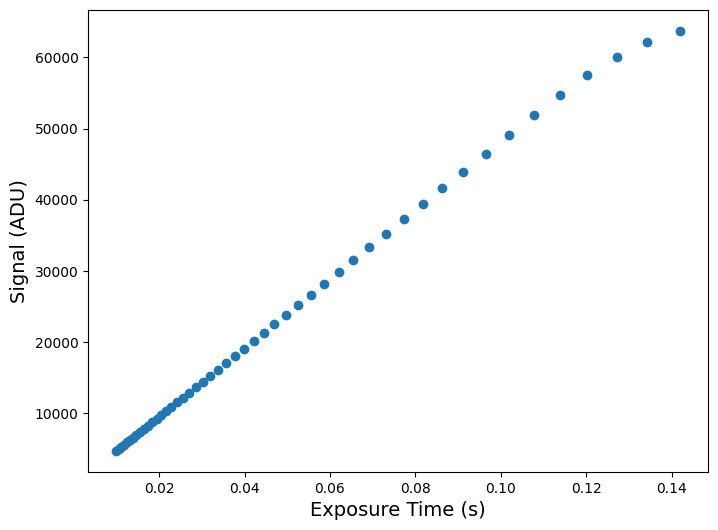

In [9]:
# now plot the ramp

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(exposure_times, signal, 'o')
ax.set_ylabel("Signal (ADU)", fontsize=14)
ax.set_xlabel("Exposure Time (s)", fontsize=14)




Fitted Gain from Variance PTC: K = 0.041 e-/ADU


Text(0.5, 1.0, 'QHY42 Variance Photon Transfer Curve (PTC): Gain = 7, Offset = 100')

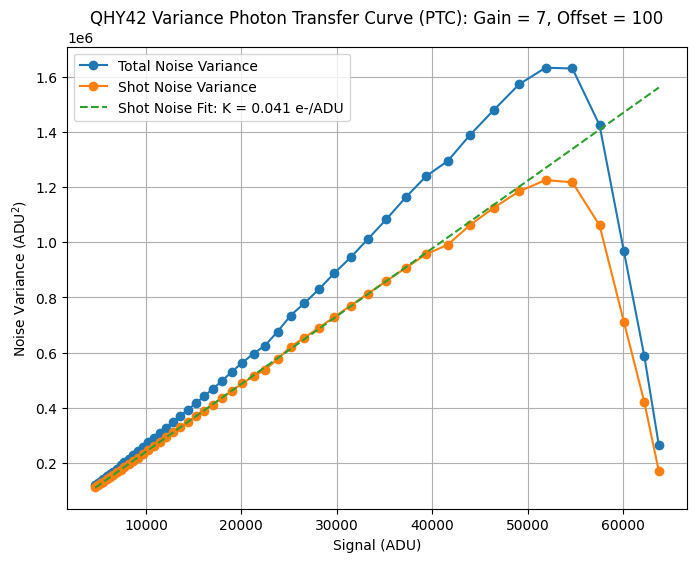

In [10]:
# Plot the Variance PTC

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(signal, sigma_total**2, 'o-', label = "Total Noise Variance")
ax.plot(signal, sigma_shot**2, 'o-', label = "Shot Noise Variance")

ax.grid(which='both')

# fit a line to the shot noise variance within the linear region
signal_linear_min = 10000  # ADU
signal_linear_max = 40000  # ADU

linear_region_mask = (signal >= signal_linear_min) & (signal <= signal_linear_max)
signal_linear = signal[linear_region_mask]
sigma_shot_linear = sigma_shot[linear_region_mask]

# fit a line to sigma_shot_linear^2 vs signal_linear
slope, intercept = np.polyfit(signal_linear, sigma_shot_linear**2, 1)

print(f"Fitted Gain from Variance PTC: K = {1/slope:.3f} e-/ADU")
ax.plot(signal, slope * signal + intercept, '--', label = "Shot Noise Fit: K = {:.3f} e-/ADU".format(1/slope))

ax.legend()

ax.set_xlabel("Signal (ADU)")
ax.set_ylabel("Noise Variance (ADU$^2$)")
ax.set_title("QHY42 Variance Photon Transfer Curve (PTC): Gain = 7, Offset = 100")


Unique exposure times (s): [0.01   0.0106 0.0112 0.0118 0.0125 0.0132 0.0139 0.0147 0.0156 0.0164
 0.0174 0.0184 0.0194 0.0205 0.0217 0.0229 0.0242 0.0256 0.027  0.0286
 0.0302 0.0319 0.0337 0.0356 0.0377 0.0398 0.0421 0.0445 0.047  0.0497
 0.0525 0.0555 0.0586 0.062  0.0655 0.0692 0.0731 0.0773 0.0817 0.0863
 0.0912 0.0964 0.1019 0.1077 0.1138 0.1202 0.1271 0.1343 0.1419 0.15  ]
Statistical Read Noise at 0.01s: 36.60 ADU


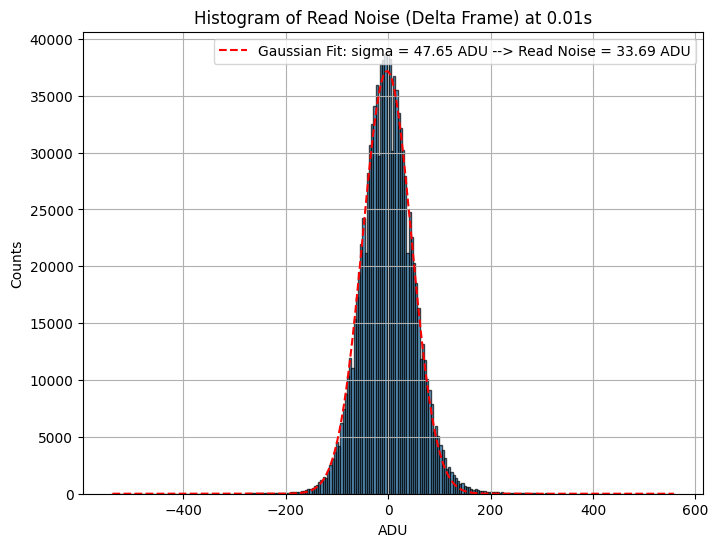

Gaussian Fit Read Noise at 0.01s: 33.69 ADU


In [11]:
# Now calculate the variance PTC pixel-wise

# process the data
unique_exposure_times = raw_df['exposure_time'].unique()

print("Unique exposure times (s):", unique_exposure_times)

# make a processed dataframe
df = raw_df.copy()

# sort the dataframe to ensure deterministic selection of first row
df = df.sort_values(
    by=["frame_type", "exposure_time", "filename"]
)

results = []

# define ROI
roi_center = (1024, 1024)  # (y, x)
roi_width = 1024  # pixels

# Now step through each unique exposure time and work through the PTC analysis
#unique_exposure_times = [0.0817]

debug_plots = False
for i, exptime in enumerate(unique_exposure_times):
    
    light_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "light")
    ]



    dark_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "dark")
    ]
    all_dark_data = dark_rows.iloc[0]["data"]

    all_light_data = light_rows.iloc[0]["data"]
    #print(f"shape of all light data before ROI: {all_light_data.shape}")

    if i==0:
        # calculate the read noise from the shortest exposure time darks
        all_dark_except_last_frame_data = dark_rows.iloc[0]["data"][:-1]
        avg_dark_except_last_frame = np.mean(all_dark_except_last_frame_data, axis=0)
        last_dark_data = dark_rows.iloc[0]["data"][-1]
        
        
    # make an average of all the dark frames for this exposure time
    avg_dark_frame = np.mean(all_dark_data, axis=0)
    avg_light_frame = np.mean(all_light_data, axis=0)

    if roi_center is not None:

        avg_light_frame = get_roi_data(avg_light_frame, roi_center, roi_width)
        avg_dark_frame = get_roi_data(avg_dark_frame, roi_center, roi_width)

        all_light_data = get_roi_data(all_light_data, roi_center, roi_width)
        all_dark_data = get_roi_data(all_dark_data, roi_center, roi_width)

        if i==0:
            avg_dark_except_last_frame = get_roi_data(avg_dark_except_last_frame, roi_center, roi_width)
            last_dark_data = get_roi_data(last_dark_data, roi_center, roi_width)
            
    if i==0:
        delta_read_noise_frame = last_dark_data - avg_dark_except_last_frame
        read_noise_stat = np.std(delta_read_noise_frame)/np.sqrt(2)
        print(f"Statistical Read Noise at {exptime}s: {read_noise_stat:.2f} ADU")
        
        # make a histogram of delta_read_noise_frame and fit with a gaussian
        plt.figure(figsize=(8,6))
        hist, bin_edges = np.histogram(delta_read_noise_frame.flatten(), bins=256)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', alpha=0.7)
        plt.title(f"Histogram of Read Noise (Delta Frame) at {exptime}s")
        plt.xlabel("ADU")
        plt.ylabel("Counts")
        plt.grid()

        # fit a gaussian to the histogram
        from scipy.optimize import curve_fit
        def gaussian(x, amp, mean, stddev):
            return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))
        gaussian_initial_guess = [np.max(hist), 0, read_noise_stat]
        popt, pcov = curve_fit(gaussian, bin_centers, hist, p0=gaussian_initial_guess)
        amp_fit, mean_fit, stddev_fit = popt   

        # update the readnoise from the fit
        read_noise = stddev_fit/np.sqrt(2)

        plt.plot(bin_centers, gaussian(bin_centers, *popt), 'r--', label=f'Gaussian Fit: sigma = {stddev_fit:.2f} ADU --> Read Noise = {read_noise:.2f} ADU')
        plt.legend()
        plt.show()
        
        print(f"Gaussian Fit Read Noise at {exptime}s: {read_noise:.2f} ADU")

    # Proceed with the rest of the analysis

    # make a frame that is the difference of the avg light and dark frames
    mean_diff_frame = avg_light_frame - avg_dark_frame
    mean_diff = np.mean(mean_diff_frame)
    
    # make the std deviation frame that is the pixel-wise std deviation of all light frames minus avg dark frame
    #print(f"shape of all light data: {all_light_data.shape}")
    diff_frames = all_light_data - avg_dark_frame  # shape (n, roi_width, roi_width)
    stddev_frame = np.std(diff_frames, axis=0)  # shape (roi_width, roi_width)

    var_frame = stddev_frame**2

    results.append({
        "exposure_time": exptime,
        "mean_light_frame": avg_light_frame,
        "mean_dark_frame": avg_dark_frame,
        "mean_frame": mean_diff_frame,
        "var_frame": var_frame,
        "stddev_frame": stddev_frame,
        "mean": mean_diff,
        "var": np.mean(var_frame),
        "std": np.mean(stddev_frame),
    })

pixelwise_results_df = pd.DataFrame(results)

In [12]:
from scipy.interpolate import CubicSpline
from typing import Optional, Tuple, Dict, Any
def fit_photon_transfer_curve_simple(
    df_filtered: pd.DataFrame
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Fit the pixel-wise photon transfer curve
    """
    # Stack all mean and variance frames
    arr_mean = np.stack(df_filtered["mean_frame"].values)
    arr_var = np.stack(df_filtered["var_frame"].values)

    # Calculate pixel-wise slope using centered differences
    x_mean = np.nanmean(arr_mean, axis=0)
    y_mean = np.nanmean(arr_var, axis=0)

    print(f"x_mean.shape: {x_mean.shape}")
    print(f"y_mean.shape: {y_mean.shape}")

    diff_x = arr_mean - x_mean
    diff_y = arr_var - y_mean

    num = np.nansum(diff_x * diff_y, axis=0)
    den = np.nansum(diff_x * diff_x, axis=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        slope_image = num / den
        slope_image[den == 0] = np.nan

    intercept_image = y_mean - slope_image * x_mean
    gain_image = 1.0 / slope_image  # gain = 1/slope

    return slope_image, intercept_image, gain_image

def fit_photon_transfer_curve_masked(
    df_filtered,
    signal_min: float = 10_000,
    signal_max: float = 40_000,
    n_plot: int = 0,
    seed: Optional[int] = 0,
    robust_percentile_clip: Optional[Tuple[float, float]] = (1.0, 99.0),
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict[str, Any]]:
    """
    Fit pixel-wise PTC: var = slope * mean + intercept, gain = 1/slope,
    using a global mask based on ROI-mean signal per exposure point.

    Args:
        df_filtered: dataframe with columns "mean_frame" and "var_frame"
                     each row corresponds to one exposure level / point.
        signal_min/max: only use exposure points whose ROI-mean(mean_frame)
                        lies within [signal_min, signal_max].
        n_plot: number of random pixels to plot for sanity check. 0 disables.
        seed: RNG seed for reproducible pixel selection.
        robust_percentile_clip:
            If not None, clip plotted y-values (variance) to these percentiles
            for nicer visualization (does NOT affect fitting).

    Returns:
        slope_image: (y, x)
        intercept_image: (y, x)
        gain_image: (y, x)
        info: dict with mask and helpful arrays
    """
    # Stack into arrays: (n_points, y, x)
    arr_mean = np.stack(df_filtered["mean_frame"].values)
    arr_var = np.stack(df_filtered["var_frame"].values)

    # Global (one-per-point) mean used to choose the fit region
    exp_means = np.array([np.nanmean(m) for m in df_filtered["mean_frame"].values])
    use = (exp_means >= signal_min) & (exp_means <= signal_max)

    if np.count_nonzero(use) < 2:
        raise ValueError(
            f"Not enough points in mask: {np.count_nonzero(use)}. "
            f"Check signal_min/max or your exp_means range."
        )

    arr_mean_fit = arr_mean[use]  # (n_fit, y, x)
    arr_var_fit = arr_var[use]

    # OLS slope per pixel (across the selected exposure points)
    x_bar = np.nanmean(arr_mean_fit, axis=0)  # (y, x)
    y_bar = np.nanmean(arr_var_fit, axis=0)

    dx = arr_mean_fit - x_bar
    dy = arr_var_fit - y_bar

    num = np.nansum(dx * dy, axis=0)
    den = np.nansum(dx * dx, axis=0)

    slope = np.divide(num, den, out=np.full_like(num, np.nan), where=(den != 0))
    intercept = y_bar - slope * x_bar
    gain = np.divide(1.0, slope, out=np.full_like(slope, np.nan), where=np.isfinite(slope) & (slope != 0))

    info = {
        "use_mask": use,
        "exp_means": exp_means,
        "signal_min": signal_min,
        "signal_max": signal_max,
        "n_points_total": arr_mean.shape[0],
        "n_points_used": int(np.count_nonzero(use)),
    }

    # -----------------------
    # Optional sanity plots
    # -----------------------
    if n_plot and n_plot > 0:
        rng = np.random.default_rng(seed)
        ny, nx = arr_mean.shape[1], arr_mean.shape[2]

        # Pick random pixel coords
        ys = rng.integers(0, ny, size=n_plot)
        xs = rng.integers(0, nx, size=n_plot)

        # 1) Show exp_means and mask
        plt.figure(figsize=(7, 4))
        idx = np.arange(len(exp_means))
        plt.plot(idx, exp_means, "o-")
        plt.axhline(signal_min, linestyle="--")
        plt.axhline(signal_max, linestyle="--")
        # highlight used points
        plt.plot(idx[use], exp_means[use], "ks", label="used")
        plt.xlabel("PTC point index")
        plt.ylabel("ROI mean signal (ADU)")
        plt.title("Global mask for pixelwise PTC fit")
        plt.grid(True, which="both")
        plt.legend()
        plt.show()

        # 2) Plot random pixel PTCs with fitted line
        for j, (yy, xx) in enumerate(zip(ys, xs), start=1):
            x_all = arr_mean[:, yy, xx]
            y_all = arr_var[:, yy, xx]

            # For plot: use only finite values
            m_all = np.isfinite(x_all) & np.isfinite(y_all)

            x_fit = arr_mean_fit[:, yy, xx]
            y_fit = arr_var_fit[:, yy, xx]
            m_fit = np.isfinite(x_fit) & np.isfinite(y_fit)

            if np.count_nonzero(m_fit) < 2 or not np.isfinite(slope[yy, xx]):
                print(f"[plot {j}] pixel (y={yy}, x={xx}) skipped (insufficient finite fit points).")
                continue

            # fitted line over the fit-range of x
            x_line = np.linspace(np.nanmin(x_fit[m_fit]), np.nanmax(x_fit[m_fit]), 100)
            y_line = slope[yy, xx] * x_line + intercept[yy, xx]

            plt.figure(figsize=(6, 5))
            plt.plot(x_all[m_all], y_all[m_all], "o", alpha=0.6, label="all points")
            plt.plot(x_fit[m_fit], y_fit[m_fit], "ks", label="used (masked)")
            plt.plot(x_line, y_line, "-", label=f"fit: slope={slope[yy,xx]:.4g}, gain={gain[yy,xx]:.4g}")

            if robust_percentile_clip is not None:
                lo, hi = robust_percentile_clip
                ylo, yhi = np.nanpercentile(y_all[m_all], [lo, hi])
                plt.ylim(ylo, yhi)

            plt.xlabel("Mean signal (ADU) [pixel]")
            plt.ylabel("Variance (ADU^2) [pixel]")
            plt.title(f"Pixel PTC sanity check {j}/{n_plot} at (y={yy}, x={xx})")
            plt.grid(True, which="both")
            plt.legend()
            plt.show()

    return slope, intercept, gain, info


In [13]:


def plot_gain_histogram(gain_image: np.ndarray, nominal_gain: float = 4.2, hist_range: Optional[Tuple[float, float]] = None):
    """
    Plot histogram of gains with analysis
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create histogram
    gain_flat = np.ravel(gain_image[~np.isnan(gain_image)])

    if hist_range is None:
        hist_range = (0, 10*max(nominal_gain, max(gain_flat)))
    hist, bins = np.histogram(gain_flat, bins=1000, range=hist_range)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax.semilogy(bin_centers, hist, ".", alpha=0.5, label="Data")
    ax.set_title("Pixel-wise PTC: Gain Histogram")

    # Fit spline to histogram peak region
    hist_clipcond = hist > 100
    if np.any(hist_clipcond):
        xhist_clip = bin_centers[hist_clipcond]
        yhist_clip = hist[hist_clipcond]

        # Spline fit
        cs = CubicSpline(xhist_clip, yhist_clip)
        xhist_fine = np.linspace(xhist_clip[0], xhist_clip[-1], 1000)
        yhist_fine = cs(xhist_fine)
        ax.plot(xhist_fine, yhist_fine, "r-", label="Spline Fit")

        # Find peak
        peak_idx = np.argmax(yhist_fine)
        peak_x = xhist_fine[peak_idx]
        peak_y = yhist_fine[peak_idx]

        print(f"Peak Gain = {peak_x:.3f} ADU/e")
        print(f"Peak Slope = {1/peak_x:.3f} e/ADU")

        ax.axvline(
            peak_x,
            color="k",
            linestyle="--",
            label=f"Peak: Gain={peak_x:.3f}, Slope={1/peak_x:.3f} e/ADU",
        )

        # Calculate FWHM
        half_max = peak_y / 2
        indices_above_half = np.where(yhist_fine > half_max)[0]
        if len(indices_above_half) > 0:
            left_idx = indices_above_half[0]
            right_idx = indices_above_half[-1]
            fwhm = xhist_fine[right_idx] - xhist_fine[left_idx]
            std_from_fwhm = fwhm / 2.355

            print(f"FWHM = {fwhm:.3f}")
            print(f"Std from FWHM = {std_from_fwhm:.3f}")

            ax.axvline(peak_x - fwhm / 2, color="b", linestyle="--", alpha=0.5)
            ax.axvline(
                peak_x + fwhm / 2,
                color="b",
                linestyle="--",
                alpha=0.5,
                label=f"FWHM={fwhm:.3f}",
            )

            # Plot 3-sigma lines
            N = 3
            ax.axvline(
                peak_x - N * std_from_fwhm, color="m", linestyle="--", alpha=0.5
            )
            ax.axvline(
                peak_x + N * std_from_fwhm,
                color="m",
                linestyle="--",
                alpha=0.5,
                label=f"±{N}σ = ±{N*std_from_fwhm:.3f}",
            )

    # Plot nominal gain
    ax.axvline(
        nominal_gain,
        color="g",
        linestyle="--",
        label=f"Nominal: Gain={nominal_gain:.3f} e/ADU",
    )

    ax.set_xlabel("Gain (e/ADU)")
    ax.set_ylabel("Number of pixels")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

def plot_slope_histogram(slope_image: np.ndarray, nominal_gain: float = 4.2, hist_range: Optional[Tuple[float, float]] = None):
    """
    Plot histogram of gains with analysis
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create histogram
    slope_flat = np.ravel(slope_image[~np.isnan(slope_image)])
    if hist_range is None:
        hist_range = (0, 10*max(1/nominal_gain, max(slope_flat)))
    hist, bins = np.histogram(slope_flat, bins=1000, range=hist_range)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax.semilogy(bin_centers, hist, ".", alpha=0.5, label="Data")
    ax.set_title("Pixel-wise PTC: Slope Histogram (Inverse Gain)")

    # Fit spline to histogram peak region
    hist_clipcond = hist > 100
    if np.any(hist_clipcond):
        xhist_clip = bin_centers[hist_clipcond]
        yhist_clip = hist[hist_clipcond]

        # Spline fit
        cs = CubicSpline(xhist_clip, yhist_clip)
        xhist_fine = np.linspace(xhist_clip[0], xhist_clip[-1], 1000)
        yhist_fine = cs(xhist_fine)
        ax.plot(xhist_fine, yhist_fine, "r-", label="Spline Fit")

        # Find peak
        peak_idx = np.argmax(yhist_fine)
        peak_x = xhist_fine[peak_idx]
        peak_y = yhist_fine[peak_idx]

        print(f"Peak Slope = {peak_x:.3f} ADU/e")
        print(f"Peak Gain = {1/peak_x:.3f} e/ADU")

        ax.axvline(
            peak_x,
            color="k",
            linestyle="--",
            label=f"Peak: Slope={peak_x:.3f}, Gain={1/peak_x:.3f} e/ADU",
        )

        # Calculate FWHM
        half_max = peak_y / 2
        indices_above_half = np.where(yhist_fine > half_max)[0]
        if len(indices_above_half) > 0:
            left_idx = indices_above_half[0]
            right_idx = indices_above_half[-1]
            fwhm = xhist_fine[right_idx] - xhist_fine[left_idx]
            std_from_fwhm = fwhm / 2.355

            print(f"FWHM = {fwhm:.3f}")
            print(f"Std from FWHM = {std_from_fwhm:.3f}")

            ax.axvline(peak_x - fwhm / 2, color="b", linestyle="--", alpha=0.5)
            ax.axvline(
                peak_x + fwhm / 2,
                color="b",
                linestyle="--",
                alpha=0.5,
                label=f"FWHM={fwhm:.3f}",
            )

            # Plot 3-sigma lines
            N = 3
            ax.axvline(
                peak_x - N * std_from_fwhm, color="m", linestyle="--", alpha=0.5
            )
            ax.axvline(
                peak_x + N * std_from_fwhm,
                color="m",
                linestyle="--",
                alpha=0.5,
                label=f"±{N}σ = ±{N*std_from_fwhm:.3f}",
            )

    # Plot nominal gain
    nominal_slope = 1 / nominal_gain
    ax.axvline(
        nominal_slope,
        color="g",
        linestyle="--",
        label=f"Nominal: Slope={nominal_slope:.3f}, Gain={nominal_gain:.3f} e/ADU",
    )

    ax.set_xlabel("Inverse Gain (ADU/e)")
    ax.set_ylabel("Number of pixels")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

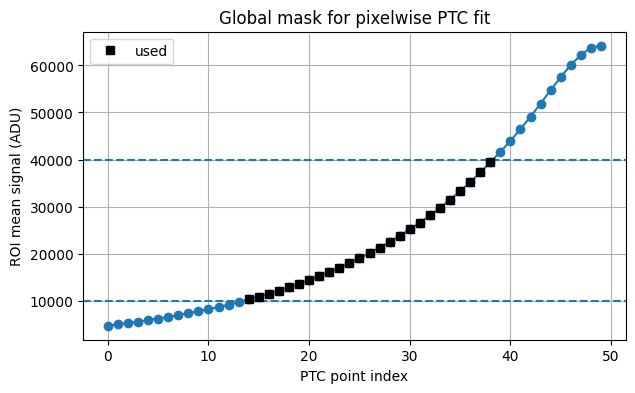

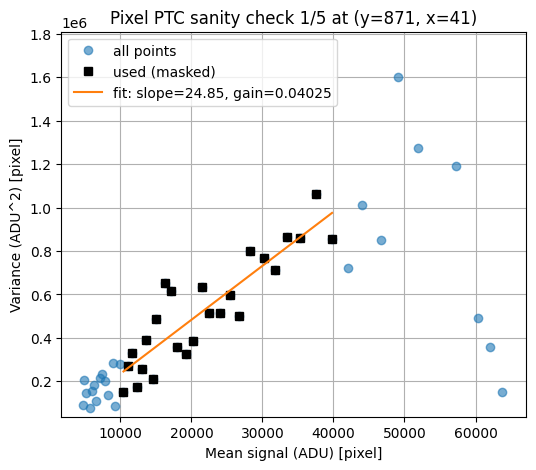

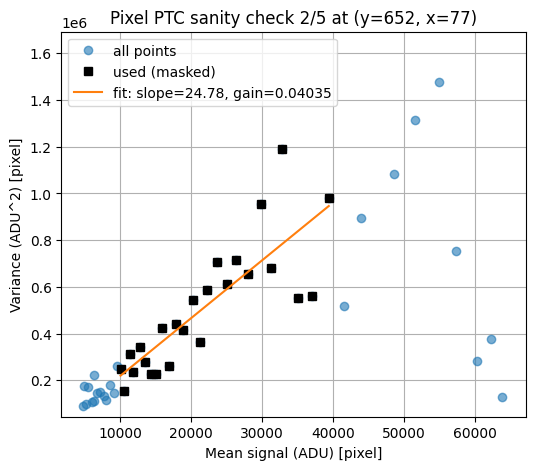

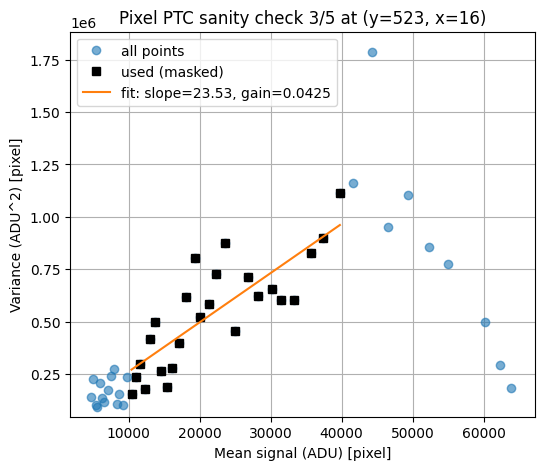

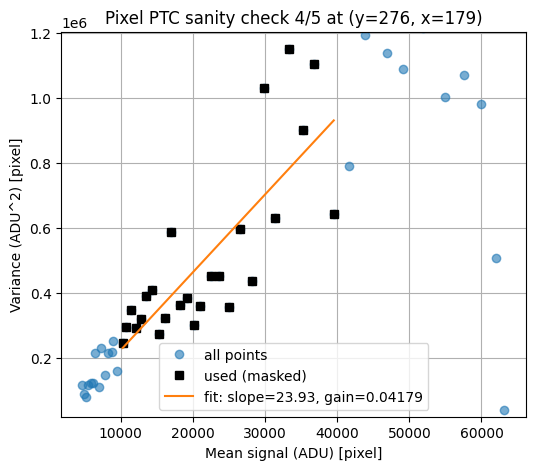

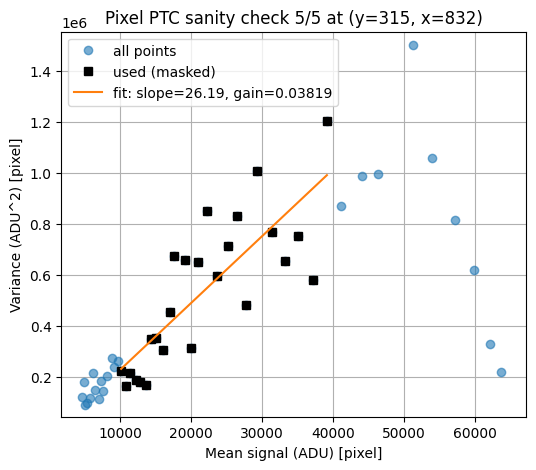

Peak Gain = 0.040 ADU/e
Peak Slope = 24.819 e/ADU
FWHM = 0.017
Std from FWHM = 0.007
Peak Slope = 23.724 ADU/e
Peak Gain = 0.042 e/ADU
FWHM = 10.220
Std from FWHM = 4.340


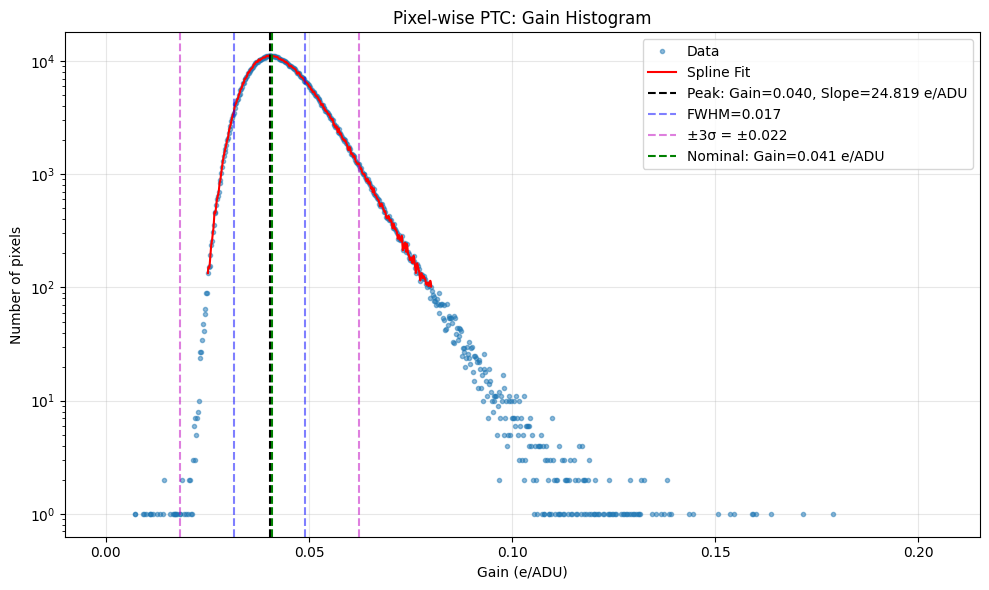

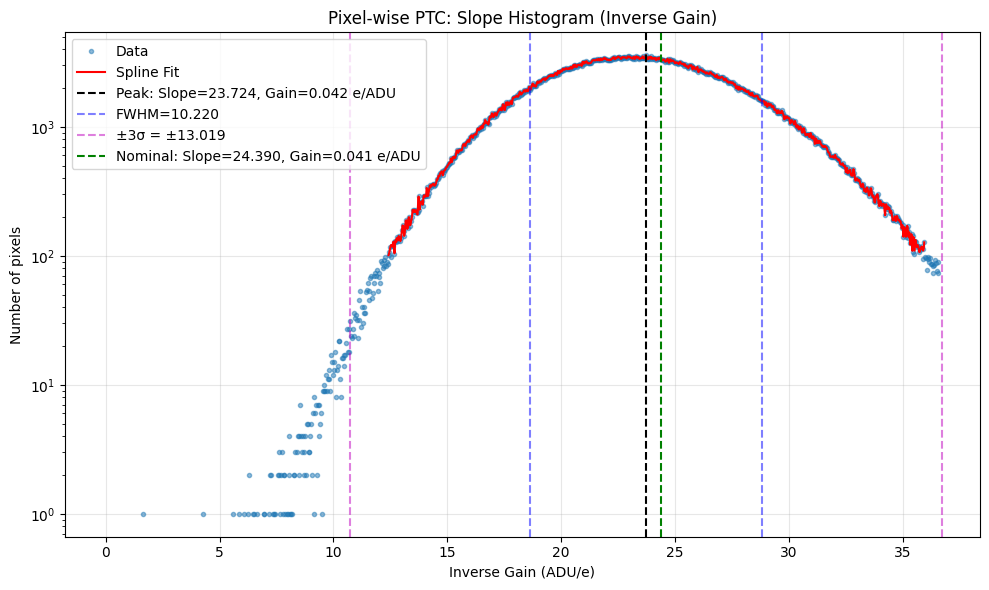

In [14]:
slope_image, intercept_image, gain_image, info = fit_photon_transfer_curve_masked(
    pixelwise_results_df,
    signal_min=10_000,
    signal_max=40_000,
    n_plot=5,
)

nominal_gain = .041  # e/ADU
fig_gain_hist = plot_gain_histogram(gain_image, nominal_gain=nominal_gain, hist_range=(0,5*nominal_gain))
fig_slope_hist = plot_slope_histogram(slope_image, nominal_gain=nominal_gain, hist_range=(0,1.5/nominal_gain))

Fitted Gain from Variance PTC: K = 0.043 e-/ADU


Text(0.5, 1.0, 'QHY42 Variance Photon Transfer Curve (PTC): Gain = 7, Offset = 100')

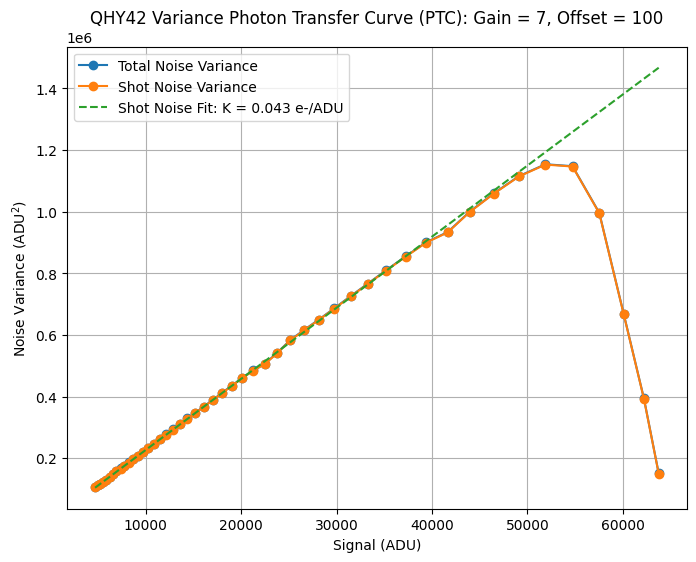

In [15]:
# variance PTC
# analyze the PTC
exposure_times = pixelwise_results_df["exposure_time"][:-1]
signal = pixelwise_results_df["mean"][:-1]
sigma_total = pixelwise_results_df["std"][:-1]
sigma_shot = np.sqrt(sigma_total**2 - read_noise**2)


fig, ax = plt.subplots(figsize=(8,6))
ax.plot(signal, sigma_total**2, 'o-', label = "Total Noise Variance")
ax.plot(signal, sigma_shot**2, 'o-', label = "Shot Noise Variance")

ax.grid(which='both')

# fit a line to the shot noise variance within the linear region
signal_linear_min = 10000  # ADU
signal_linear_max = 40000  # ADU

linear_region_mask = (signal >= signal_linear_min) & (signal <= signal_linear_max)
signal_linear = signal[linear_region_mask]
sigma_shot_linear = sigma_shot[linear_region_mask]

# fit a line to sigma_shot_linear^2 vs signal_linear
slope, intercept = np.polyfit(signal_linear, sigma_shot_linear**2, 1)

print(f"Fitted Gain from Variance PTC: K = {1/slope:.3f} e-/ADU")
ax.plot(signal, slope * signal + intercept, '--', label = "Shot Noise Fit: K = {:.3f} e-/ADU".format(1/slope))

ax.legend()

ax.set_xlabel("Signal (ADU)")
ax.set_ylabel("Noise Variance (ADU$^2$)")
ax.set_title("QHY42 Variance Photon Transfer Curve (PTC): Gain = 7, Offset = 100")

